# Cancer Diagnosis Model

## Introduction and Overview

Gene expression profiles can provide key insights to cell type, function, and health. Cells in different tissues often express vastly different genes, allowing them to specialize in their functionality. In cancerous cells, however, gene expression is atypical for a cell of its type. In other words, high expression of a gene in one cell type can be normal whereas it can be indicative of cancer in another cell type. These anomalies can therefore be used to classify cells into different cancer types based on their gene expression. This notebook will demonstrate how to develop a multi-class supervised machine learning model to use gene expression profiles to predict cancer type.

The datasets used in this project were provided by The Cancer Genomic Atlas (TCGA). The first dataset, "gene expression RNAseq - Batch effects normalized mRNA data", contains the gene expression profiles for various tissue samples (link: https://xenabrowser.net/datapages/?dataset=EB%2B%2BAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena&host=https%3A%2F%2Fpancanatlas.xenahubs.net&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443). In this dataset, rows represent genes, columns represent samples, and table values represent gene expression as a floating point value, measured in log2(norm_value+1). In order to properly join this table to the second dataset, the gene expression dataset will be transposed such that rows represent samples and columns represent genes.

The second dataset, titled "phenotype - Curated clinical data", contains patient survival data (link: https://xenabrowser.net/datapages/?dataset=Survival_SupplementalTable_S1_20171025_xena_sp&host=https%3A%2F%2Fpancanatlas.xenahubs.net&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443). In this dataset, rows represent samples, columns represent clinical metrics, and table values are measurements of various data types. Although many of the features in this dataset are not relevant to this study, this dataset contains a feature titled "cancer type abbreviation", which includes three to four letter string codes representing the cancer diagnosis of the patient (cancer abbreviations can be referenced here: https://gdc.cancer.gov/resources-tcga-users/tcga-code-tables/tcga-study-abbreviations). These nominal categorical labels will be the predicted output of the model.

Prior to model development, careful manipulation of the aforementioned datasets is required. Importantly, the cancer diagnosis is prescribed to the patient, not the sample. Further, a single patient may have multiple samples. Lastly, samples can be from various tissue types. Luckily, the TCGA provides an intuitive, four-part naming system for sample names in the form "TCGA-{site code}-{patient code}-{sample type code}". Note that a sample type code of "01" represents a primary tumor (ie, that sample is responsible for the diagnosis of the patient).

To account for these nuances, all samples not of sample type "01" will be disregarded. Patient codes will then be extracted from sample barcodes in order to group samples by patient in later analysis. The two tables will finally be joined on sample ID.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from scipy import stats
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Pre-processing

## Load and clean gene expression dataset

In [2]:
# Load the gene expression file (transpose the csv so that columns are genes and rows are samples)
gene_df = pd.read_csv("data/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena", sep="\t", index_col=0).T.astype("float32")
gene_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11069 entries, TCGA-OR-A5J1-01 to TCGA-CG-4477-01
Columns: 20531 entries, 100130426 to ZZZ3
dtypes: float32(20531)
memory usage: 867.0+ MB


Because there are sufficient records in the table, and because memory is a concern (the raw file uses 867+ MBs of storage, even after down-casting numeric values to float32), NAs will be dropped from the table.

In [3]:
# Drop NAs and duplicates
gene_df.dropna(inplace=True)
gene_df.drop_duplicates(inplace=True)
gene_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9318 entries, TCGA-OR-A5J1-01 to TCGA-HF-7131-01
Columns: 20531 entries, 100130426 to ZZZ3
dtypes: float32(20531)
memory usage: 730.1+ MB


Because outliers in genomics and bioinformatics often hold valid biological significance, a conservative z-score of 5 will be used to detect outliers.

In [4]:
# Check for outliers
numeric_cols = [col for col in gene_df.select_dtypes(include=["number"])]
print(f"There are {len(numeric_cols)} cols")
ol_cols = 0
z_scores = stats.zscore(gene_df[numeric_cols])
for col, zs in zip(numeric_cols, z_scores.T):
    ols = np.sum(np.abs(zs) > 5)
    if ols > 0:
        ol_cols += 1
print(f"There are {ol_cols} outlier cols")

There are 20531 cols
There are 11014 outlier cols


Again, the large number of columns containing outliers is not surprising given the nature of the dataset; the expression of some genes in cancer cells can be far out of range of their typical expression distribution. Given the high likelihood for biological significance, the vast amount of features with extreme outliers, and the quality of the dataset itself (provided by the NIH), these outliers will be kept. Nonetheless, they are worth noting.

## Load and clean diagnosis dataset

In [5]:
# Load the survival (ie, patient) file
diagnosis_df = pd.read_csv("data/Survival_SupplementalTable_S1_20171025_xena_sp", sep="\t", index_col=0)
diagnosis_df.head()
print(diagnosis_df.columns)

Index(['_PATIENT', 'cancer type abbreviation',
       'age_at_initial_pathologic_diagnosis', 'gender', 'race',
       'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type',
       'histological_grade', 'initial_pathologic_dx_year', 'menopause_status',
       'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to',
       'death_days_to', 'cause_of_death', 'new_tumor_event_type',
       'new_tumor_event_site', 'new_tumor_event_site_other',
       'new_tumor_event_dx_days_to', 'treatment_outcome_first_course',
       'margin_status', 'residual_tumor', 'OS', 'OS.time', 'DSS', 'DSS.time',
       'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction'],
      dtype='object')


As shown above, most of the columns in this dataset are not relevant to the model. All columns other than sample (the index, used for joining), _PATIENT (used for grouping samples), and cancer type abbreviation (class of cancer)  will be excluded.

In [6]:
# Remove irrelevant cols, handle NAs, drop duplicates
diagnosis_df.drop_duplicates(inplace=True)
diagnosis_df = diagnosis_df[["_PATIENT", "cancer type abbreviation"]]
diagnosis_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11081 entries, TCGA-OR-A5J1-01 to TCGA-YZ-A985-01
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   _PATIENT                  11081 non-null  object
 1   cancer type abbreviation  11081 non-null  object
dtypes: object(2)
memory usage: 259.7+ KB


As shown above, there are no nulls in this dataframe. Now, samples will be grouped by patient to prevent data leakage. Only the samples from primary tumors (ie, with sample names ending in -01) will be included for each patient, as these are the samples responsible for the cancer diagnosis.

In [7]:
# First create sample type column, then group by patient
diagnosis_df["sample_type"] = diagnosis_df.index.str[-2:]
diagnosis_df = diagnosis_df.loc[diagnosis_df["sample_type"] == "01"]
diagnosis_df.head()

,_PATIENT,cancer type abbreviation,sample_type
sample,,,
TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC,01
TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC,01
TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC,01
TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC,01
TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC,01


## Join gene expression and diagnosis data dataframes

In [8]:
# Join the two tables to create cancer_df
cancer_df = pd.merge(gene_df, diagnosis_df, left_index=True, right_index=True, how='inner')
cancer_df.index.name = 'sample'
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8080 entries, TCGA-OR-A5J1-01 to TCGA-HF-7131-01
Columns: 20534 entries, 100130426 to sample_type
dtypes: float32(20531), object(3)
memory usage: 633.1+ MB


In [9]:
# Delete old dfs to save memory
del gene_df
del diagnosis_df

# EDA

Given the sheer size of the dataset, many traditional EDA techniques are not applicable here and many visualizations are infeasible for so many features. Class imbalance will still be visualized below, as it is a key metric that will significantly impact model development.

### Check if output class is imbalanced

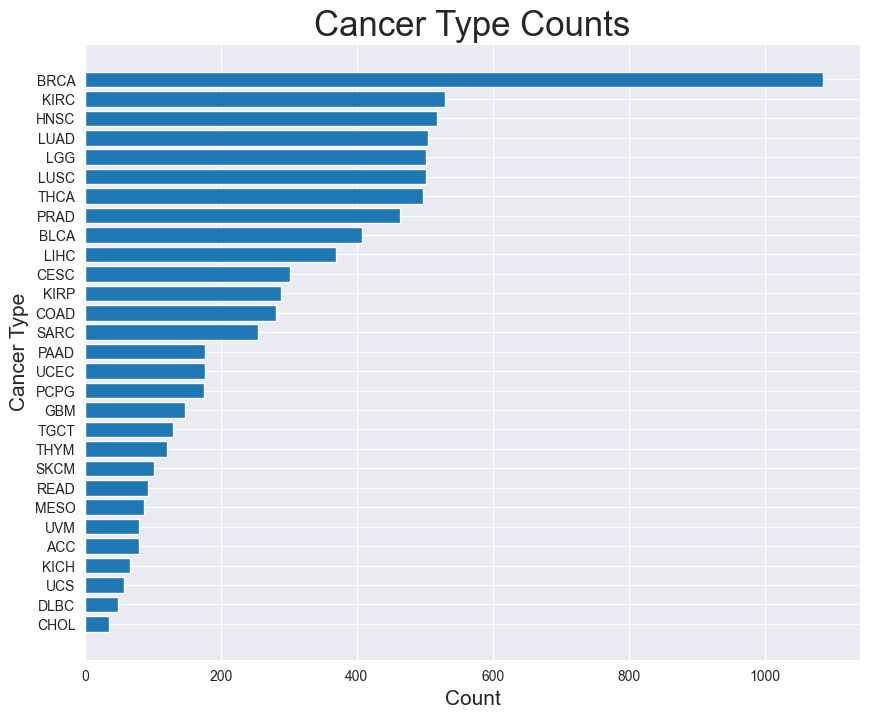

In [43]:
# Display value counts of each output class to visualize the degree to which the dataset is imbalanced
cancer_counts = cancer_df["cancer type abbreviation"].value_counts()
plt.figure(figsize=(10,8))
plt.grid(True)
plt.barh(cancer_counts.index, cancer_counts.values)
plt.title("Cancer Type Counts", fontsize=25)
plt.xlabel("Count", fontsize=15)
plt.ylabel("Cancer Type", fontsize=15)
plt.gca().invert_yaxis()
plt.savefig("Class imbalance.png", dpi=300)
plt.show()

In [11]:
print(cancer_counts)

cancer type abbreviation
BRCA    1086
KIRC     530
HNSC     518
LUAD     504
LUSC     501
LGG      501
THCA     497
PRAD     463
BLCA     407
LIHC     369
CESC     302
KIRP     289
COAD     281
SARC     255
PAAD     177
UCEC     176
PCPG     175
GBM      147
TGCT     129
THYM     120
SKCM     101
READ      92
MESO      87
UVM       80
ACC       79
KICH      66
UCS       57
DLBC      48
CHOL      36
STAD       3
OV         2
ESCA       2
Name: count, dtype: int64


As shown by the bar chart above, the output classes are highly imbalanced. For example, the most frequent cancer type (BRCA) has roughly twice as many records as the second most frequent cancer type (KIRC). Further, some cancers such as SCA, STAD, and OV have nearly no associated records. In order to develop an accurate model, SMOTE will be applied below to oversample the minority classes. STAD, OV, and ESCA each have less than 5 records and would therefore be statistically unreasonable to include in the model. Therefore, these three classes will be dropped entirely.

In [12]:
# Drop extreme minority classes
cancer_df = cancer_df[~cancer_df["cancer type abbreviation"].isin(["STAD", "OV", "ESCA"])]
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8073 entries, TCGA-OR-A5J1-01 to TCGA-ZU-A8S4-01
Columns: 20534 entries, 100130426 to sample_type
dtypes: float32(20531), object(3)
memory usage: 632.5+ MB


Now that class imbalance has been identified and extreme imbalanced classes have been dropped from the dataset, it is nearly time to begin model development. However, the dimensionality of the feature space must first be substantially reduced, as 20,000 input features is far too many for most models. Rather than relying on common feature selection techniques such as filtering, embedding, and wrapping, PCA will be deployed below to greatly reduce the number of features as it is more scalable for a dataset this large. Further, using PCA will remove any multi-collinearity concerns, as principal components are, by definition, orthogonal and linearly independent. Note that PCA requires that the dataset be centered and scaled, so sklearn's StandardScaler will be used to transform input features.

# Training and Testing

## Train-Test Splitting

From categories of Classification supervised learning, Regression supervised learning
or unsupervised learning, select three models,
* Develop these three models, using proper parameters
* What does these parameters mean? What values you set?
* Any prediction?

Note that, because there can be many samples per patient, it is important to group samples by patient when dividing the dataset into training and testing sets to prevent data leakage. Therefore, rather than using sklearn's train_test_split, sklearn's GroupShuffleSplit will be used to create the training and testing sets.

In [13]:
# Train test split
X = cancer_df.drop((["_PATIENT", "sample_type", "cancer type abbreviation"]), axis=1)
y = cancer_df["cancer type abbreviation"]
patients = cancer_df["_PATIENT"]

# Get train and test indices
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=patients))

# Instantiate train and test sets
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Show group counts of y_train
counts = y_train.value_counts()
print(counts)

cancer type abbreviation
BRCA    860
KIRC    436
HNSC    413
LGG     413
LUAD    403
LUSC    401
THCA    389
PRAD    364
BLCA    315
LIHC    294
CESC    238
KIRP    237
COAD    234
SARC    200
UCEC    140
PCPG    136
PAAD    136
GBM     113
TGCT    108
THYM    100
SKCM     85
READ     82
MESO     74
UVM      70
ACC      57
KICH     56
UCS      38
DLBC     38
CHOL     28
Name: count, dtype: int64


## PCA on X_train for Feature Extraction

PCA will be performed on the X_train data only. This prevents data leakage from the test set and prevents the model from having overly-optimistic metrics. Note that the PCA model below will not be used in cross validation, as each fold must undergo PCA to prevent data leakage. The following analysis is simply to determine the number of principal components to use in later steps.

In [14]:
eda_scaler = StandardScaler()
scaled_X_train = eda_scaler.fit_transform(X_train)
eda_pca = PCA(n_components=250)
eda_pca = eda_pca.fit(scaled_X_train)

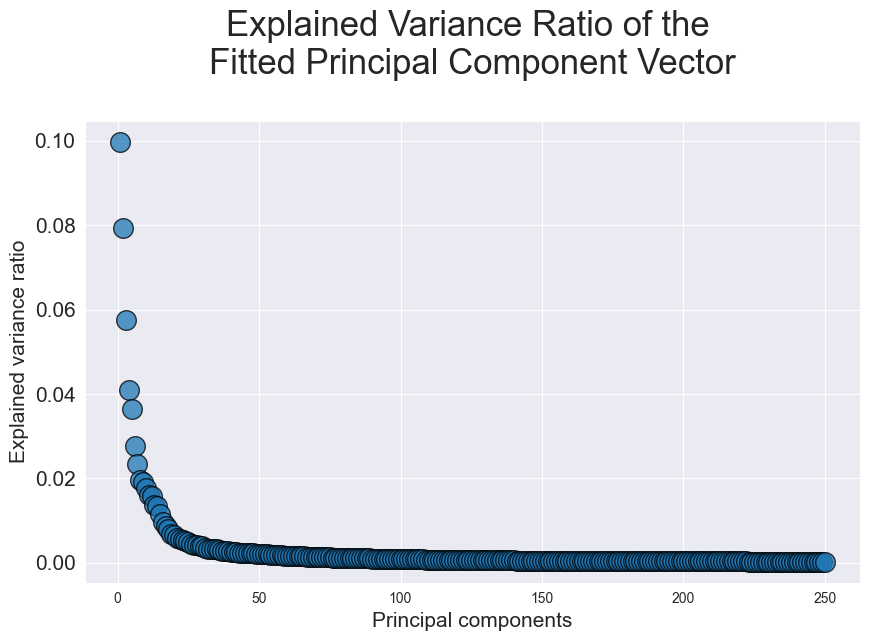

In [33]:
# Visualize principal component explained variance
plt.figure(figsize=(10,6))
plt.grid(True)
plt.scatter(x=[i+1 for i in range(len(eda_pca.explained_variance_ratio_))],
            y=eda_pca.explained_variance_ratio_,
           s=200, alpha=0.75,edgecolor='k')
plt.title("Explained Variance Ratio of the \nFitted Principal Component Vector\n",fontsize=25)
plt.xlabel("Principal components",fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Explained variance ratio",fontsize=15)
plt.savefig("Explained_Variance_Ratio.png", dpi=300)
plt.show()

In [16]:
# Print percentage of explained variance of first 30 principal components
print(f"Percent variance explained by first 30 Principal Components: {sum(eda_pca.explained_variance_ratio_[:30]) * 100}%")
print(f"Percent variance explained by first 100 Principal Components: {sum(eda_pca.explained_variance_ratio_[:100]) * 100}%")
print(f"Percent variance explained by first 250 Principal Components: {sum(eda_pca.explained_variance_ratio_) * 100}%")

Percent variance explained by first 30 Principal Components: 58.090232849121094%
Percent variance explained by first 100 Principal Components: 70.2056884765625%
Percent variance explained by first 250 Principal Components: 77.23271179199219%


As shown above, the elbow point of diminishing marginal returns occurs at roughly 30 principal components. These components account for roughly 58% of the variance in the data, which likely is not enough for the model. However, using all 250 principal components will likely result in extremely poor performance, as SMOTE's performance is extremely sensitive to the dimensionality of the dataset. Therefore, only the first 100 principal components will be used, as they still explain about 70% of the variance in the original dataset and won't affect performance as drastically as all 250 principal components.

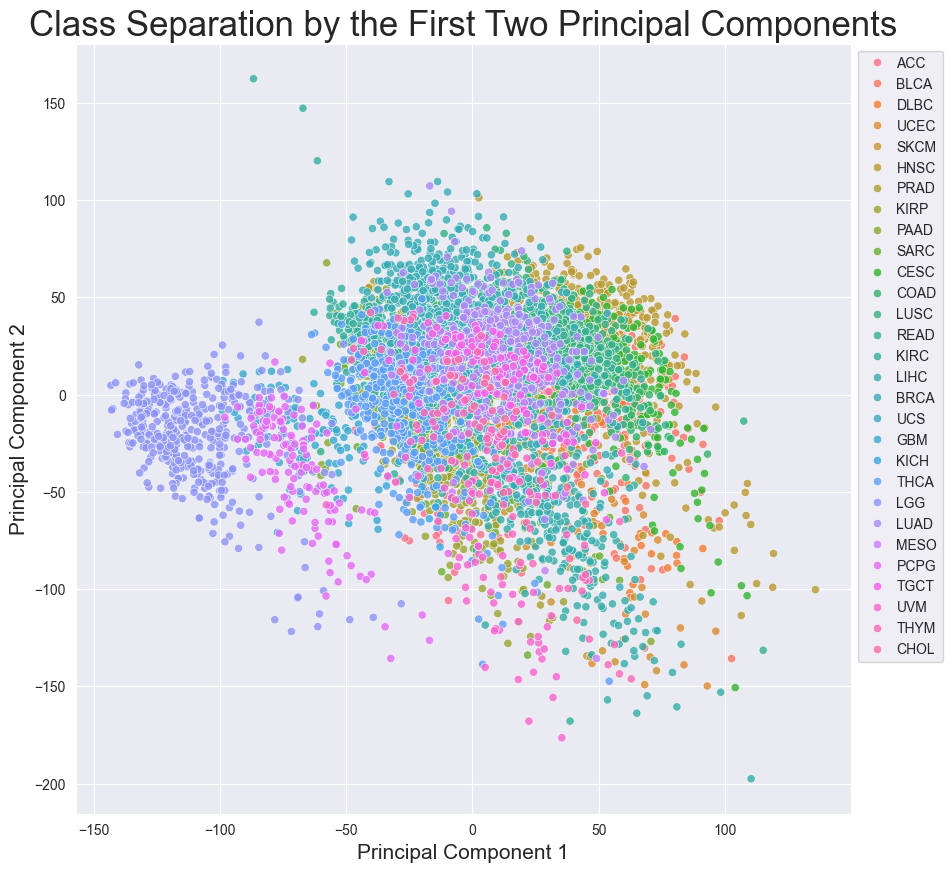

In [42]:
# Show class separation by the first two Principal Components
final_pca = PCA(n_components=100)
final_pca = final_pca.fit(scaled_X_train)
pca_X_train = final_pca.transform(scaled_X_train)
plt.figure(figsize=(10,10))
sns.scatterplot(x=pca_X_train[:, 0], y=pca_X_train[:, 1], hue=y_train.values, alpha=0.8)
plt.title("Class Separation by the First Two Principal Components", fontsize=25)
plt.xlabel("Principal Component 1", fontsize=15)
plt.ylabel("Principal Component 2", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

As shown by the plot above, the first two principal components alone do not separate the cancer types very well, as many cancer types have overlapping clusters centered around (0,0). However, some cancers such as LGG and TGCT do in fact exhibit decent separation from other cancer types, particularly along the first principal component. Of course, visualizing all 29 cancer types in 100 dimensional space is not possible, but this simple plot demonstrates that initial class separation has been achieved with only the first two principal components.

In [18]:
print(f"The initial dataset had {len(X_train.columns)} features. PCA dropped the dimensionality of the"
      f"training dataset to {pca_X_train.shape[1]}, resulting in approximately a {int(len(X_train.columns) / pca_X_train.shape[1])}-fold reduction in the dimensionality of the training dataset.")

The initial dataset had 20531 features. PCA dropped the dimensionality of thetraining dataset to 100, resulting in approximately a 205-fold reduction in the dimensionality of the training dataset.


## Model Selection and Training without Cross Validation

Logistic Regression, Random Forest, and XGBoost were chosen as candidate models for this project due to their ability to handle multi-class classification tasks. Before cross validating, each model will be tested to establish a baseline for subsequent model evaluation. All models below will implement PCA as described above, as well as SMOTE oversampling to account for class imbalance.

### Logistic Regression

In [19]:
# Use StandardScaler from above
scaled_X_train = eda_scaler.transform(X_train)
scaled_X_test = eda_scaler.transform(X_test)

base_pca = PCA(n_components=100)
pca_X_train = base_pca.fit_transform(scaled_X_train)
base_X_test = base_pca.transform(scaled_X_test)
smote = SMOTE(random_state=42)
base_X_train, base_y_train = smote.fit_resample(pca_X_train, y_train)

base_lrclf = LogisticRegression(max_iter=250, solver='saga', class_weight='balanced', n_jobs=-1)
base_lrclf.fit(base_X_train, base_y_train)
base_lrclf_score = base_lrclf.score(base_X_test, y_test)

print(f"Logistic Regression has a base score of {base_lrclf_score}")


Logistic Regression has a base score of 0.9529411764705882


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Note: the warning above simply indicates that the logistic regression classifier did not converge after 250 iterations. This is likely due to the relatively large number of features being used by the model (100 PCs). Regardless, 250 max iterations will be kept above, as more iterations would significantly increase training time, and this first model is simply used to get a baseline of model accuracy.

### Random Forest

In [20]:
base_rfclf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
base_rfclf.fit(base_X_train, base_y_train)
base_rfclf_score = base_rfclf.score(base_X_test, y_test)

print(f"Random Forest has a base score of {base_rfclf_score}")

Random Forest has a base score of 0.9442724458204335


### XGBoost

In [21]:
# XGBoost requires integer labels
le = LabelEncoder()
base_y_train_le =le.fit_transform(base_y_train)
base_y_test_le =le.transform(y_test)

base_xgb = XGBClassifier(learning_rate=0.1, n_jobs=-1, random_state=42)
base_xgb.fit(base_X_train, base_y_train_le)
base_xgb_score = base_xgb.score(base_X_test, base_y_test_le)

print(f"XGBoost has a base score of {base_xgb_score}")

XGBoost has a base score of 0.934984520123839


Note that very high scores for the above models. These scores are overly-optimistic, as they are likely overfit due to lack of cross validation.

## Model Selection and Training with Cross Validation

The models will be improved below using group-aware cross validation. This ensures that models are not overfit, and that multiple samples from a given patient are grouped together in the same fold during cross validation to prevent data leakage. Note that imblearn's Pipeline will be used to chain scaling, PCA, SMOTE, and the classifier. This further prevents data leakage, as these operations are performed on each fold rather than the entire training dataset.

### Logistic Regression Cross Validation

In [22]:
# Logistic Regression
# Use group-aware cross validation
gkf = GroupKFold(n_splits=3) # use fewer folds to reduce computational costs
initial_lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('smote', SMOTE(random_state=42)),
    ('lrclf', LogisticRegression(random_state=42,
                                 max_iter=250,
                                 penalty="l2", # l2 regularization to prevent overfitting
                                 class_weight='balanced', # use to balance input instead of SMOTE, which isn't scalable
                                 solver="saga", # for high-dimensional data
                                 n_jobs=-1))
])

lr_scores = cross_val_score(initial_lr_pipe, X_train, y_train, cv=gkf, groups=patients.iloc[train_idx])
lr_score = lr_scores.mean()
print(f"Logistic Regression has a score of {lr_score} with cross validation.")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression has a score of 0.9489001543047338 with cross validation.


Note: as with the previous logistic regression classifier, the warnings above simply indicate that the new classifiers did not converge after 250 iterations. This is likely due to the relatively large number of features being used by the model (100 PCs). Despite the model not converging, the model's high score is well within the acceptable range. Therefore, the max_iter was kept to 250 to limit training time, although increasing the value for this parameter could lead to convergence.

### Random Forest Cross Validation

In [23]:
# Random Forest
# Tree-based, so do not need to apply StandardScaler or PCA in a pipeline
initial_rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('smote', SMOTE(random_state=42)),
    ('rfclf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1))
])

rf_scores = cross_val_score(initial_rf_pipe, X_train, y_train, cv=gkf, groups=patients.iloc[train_idx])
rf_score = rf_scores.mean()
print(f"Random Forest has an score of {rf_score} with cross validation.")

Random Forest has an score of 0.9363582183529969 with cross validation.


### XGBoost Cross Validation

In [24]:
# XGBoost
y_train_le = le.transform(y_train)

initial_xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('smote', SMOTE(random_state=42)),
    ('xgbclf', XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y_train_le)), n_jobs=-1))
])

xgbclf_scores = cross_val_score(initial_xgb_pipe, X_train, y_train_le, cv=gkf, groups=patients.iloc[train_idx])
xgbclf_score = xgbclf_scores.mean()

print(f"XGB Classifier has a score of {xgbclf_score} with cross validation.")

XGB Classifier has a score of 0.9292355095423175 with cross validation.


# Tuning

The models above will be tuned using sklearn's GridSearchCV to perform grid search on the parameters to test. The best parameters and their respective scores will be printed for each model below. Note that the search space will be relatively small for each model to limit excessive training times.

## Logistic Regression Tuning

For logistic regression, only the C and penalty parameters will be tuned. The C term controls the strength of the regularization term, where a smaller value results in a higher penalty. Both L1 and L2 regularization will be tested, as indicated by the penalty parameters. The solver is held constant as 'saga', as this solver supports multinomial classification as well as both L1 and L2 regularization. class_weight is also held constant to account for class imbalance. Lastly, max_iter is held constant at 250. As previously mentioned, this results in failure to converge warnings, but was chosen to limit excessive training times.

In [25]:
# Logistic Regression Tuning
# Preface params with lrclf__ to allow grid search to properly search parameter grid within pipeline
lr_params = {
    'lrclf__C': [0.1, 1, 10],
    'lrclf__penalty': ['l1', 'l2'],
}

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('smote', SMOTE(random_state=42)),
    ('lrclf', LogisticRegression(solver='saga', class_weight='balanced', max_iter=250, random_state=42, n_jobs=-1))
])

lrclf = GridSearchCV(estimator=lr_pipe,
                  param_grid=lr_params,
                  cv=gkf,
                  n_jobs=1,
                  verbose=2) # to track progress
lrclf.fit(X_train, y_train, groups=patients.iloc[train_idx])
final_lrclf = lrclf.best_estimator_
print(lrclf.best_params_)
print(lrclf.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ....................lrclf__C=0.1, lrclf__penalty=l1; total time=  34.9s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ....................lrclf__C=0.1, lrclf__penalty=l1; total time=  39.4s


...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................lrclf__C=10, lrclf__penalty=l2; total time=  20.5s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................lrclf__C=10, lrclf__penalty=l2; total time=  20.7s
{'lrclf__C': 0.1, 'lrclf__penalty': 'l1'}
0.9507583867586854


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Note: as with the previous logistic regression classifiers, the warnings above simply indicate that the new classifiers did not converge after 250 iterations. This is likely due to the relatively large number of features being used by the model (100 PCs). Despite the model not converging, the model's high score is well within the acceptable range. Therefore, the max_iter was kept to 250 to limit training time, although increasing the value for this parameter could lead to convergence.

## Random Forest Tuning

For random forest, the n_estimators, max_depth, and min_samples_leaf will be tuned. n_estimators controls the number of trees in the forest, max_depth limits the maximum depth of each tree in the forest, and min_samples_leaf controls the minimum amount of samples required for each leaf node in each tree. As with logistic regression, the class_weight parameter is held constant to account for class imbalance.

In [26]:
# Random Forest Tuning
# Preface params with rfclf__ to allow grid search to properly search parameter grid within pipeline
rf_params = {
    'rfclf__n_estimators': [50, 100, 200],
    'rfclf__max_depth': [None, 5, 10],
    'rfclf__min_samples_leaf': [1, 5, 10],
}

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('smote', SMOTE(random_state=42)),
    ('rfclf', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced'))
])

rfclf = GridSearchCV(estimator=rf_pipe,
                  param_grid=rf_params,
                  cv=gkf,
                  n_jobs=1,
                  verbose=2) # to track progress
rfclf.fit(X_train, y_train, groups=patients.iloc[train_idx])
final_rfclf = rfclf.best_estimator_
print(rfclf.best_params_)
print(rfclf.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=50; total time=   4.3s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=50; total time=   4.3s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=50; total time=   4.3s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=100; total time=   5.5s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=100; total time=   5.4s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=100; total time=   5.3s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=200; total time=   8.7s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=200; total time=   8.7s
[CV] END rfclf__max_depth=None, rfclf__min_samples_leaf=1, rfclf__n_estimators=200; total time=   8.9s
[CV] END rfclf_

## XGBoost Tuning

For XGBoost, the n_estimators, max_depth, and learning_rate will be tuned. n_estimators controls the number of trees in the forest and  max_depth limits the maximum depth of each tree in the forest. The learning_rate parameter controls the step size of the model, or the amount by which the model updates tree weights. The objective and num_class parameters are held constant to 'multi:softmax' and len(np.unique(y_train_le)), respectively. This allows XGBoost to perform multiclass classification, and num_class simply specifies the number of classes.

In [27]:
# XGBoost Tuning
# Convert X_train to numpy for XGBoost
X_train_np = X_train.to_numpy()

# Preface params with xgbclf__ to allow grid search to properly search parameter grid within pipeline
xgb_params = {
    'xgbclf__n_estimators': [100, 200],
    'xgbclf__learning_rate': [0.01, 0.1],
    'xgbclf__max_depth': [3, 5]
}

xgb_estimator = XGBClassifier(objective='multi:softmax',
                                 num_class=len(np.unique(y_train_le)),
                                 n_jobs=-1,
                                 random_state=42)

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('smote', SMOTE(random_state=42)),
    ('xgbclf', xgb_estimator),
])

xgbclf = GridSearchCV(estimator=xgb_pipe,
                   param_grid=xgb_params,
                   cv=gkf,
                   n_jobs=1,
                   verbose=2) # to track progress
xgbclf.fit(X_train_np, y_train_le, groups=patients.iloc[train_idx])
final_xgbclf = xgbclf.best_estimator_
print(xgbclf.best_params_)
print(xgbclf.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=3, xgbclf__n_estimators=100; total time=   7.2s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=3, xgbclf__n_estimators=100; total time=   7.3s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=3, xgbclf__n_estimators=100; total time=   7.2s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=3, xgbclf__n_estimators=200; total time=  12.2s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=3, xgbclf__n_estimators=200; total time=  12.0s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=3, xgbclf__n_estimators=200; total time=  12.1s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=5, xgbclf__n_estimators=100; total time=  10.9s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=5, xgbclf__n_estimators=100; total time=  11.2s
[CV] END xgbclf__learning_rate=0.01, xgbclf__max_depth=5, xgbclf__n_estimators=100; total time=  10.4s
[CV] END xgbc

# Metrics

## Comparison of Non-CV, CV, and Tuned Models

Before doing an in-depth review of the final tuned models, the scores will be compared for the base models, cross-validated models, and tuned models, for each classifier.

In [28]:
# Logistic Regression Model Comparison
print(f"Base Logistic Regression Score: {base_lrclf_score:.3f}")
print(f"Cross-Validated Logistic Regression Score: {lr_score:.3f}")
print(f"Tuned Logistic Regression Score: {lrclf.best_score_:.3f}")

Base Logistic Regression Score: 0.953
Cross-Validated Logistic Regression Score: 0.949
Tuned Logistic Regression Score: 0.951


In [29]:
# Random Forest Model Comparison
print(f"Base Random Forest Score: {base_rfclf_score:.3f}")
print(f"Cross-Validated Random Forest Score: {rf_score:.3f}")
print(f"Tuned Random Forest Score: {rfclf.best_score_:.3f}")

Base Random Forest Score: 0.944
Cross-Validated Random Forest Score: 0.936
Tuned Random Forest Score: 0.937


In [30]:
# XGBoost Model Comparison
print(f"Base XGBoost Score: {base_xgb_score:.3f}")
print(f"Cross-Validated XGBoost Score: {xgbclf_score:.3f}")
print(f"Tuned XGBoost Score: {xgbclf.best_score_:.3f}")

Base XGBoost Score: 0.935
Cross-Validated XGBoost Score: 0.929
Tuned XGBoost Score: 0.936


Logistic Regression and XGBoost both performed slightly worse when cross validated compared to the base models. This can be a result of overfitting in the base model - although the score is slightly worse for the cross-validated models, it is closer to the truth, whereas the scores for base models without cross validation are likely over-optimistic. Group-aware cross-validation, therefore, was used to directly address overfitting. Hyperparameter tuning after cross validation marginally improved the performance of logistic regression and XGBoost, suggesting that the default parameters are already nearly optimal. To further prevent overfitting, both L1 and L2 regularization were tested for the logistic regression classifier during hyperparameter tuning. Grid search revealed that L2 regularization resulted in better generalization than L1.

Unlike logistic regression and XGBoost, the Random Forest cross-validated model performed slightly better than the base model. Given that this improvement is marginal, I suspect that this is because the base model was not overfit and the marginal improvement is simply due to noise.

Hyperparameter tuning after cross validation marginally improved the performance of all three models, suggesting that the default parameters were already nearly optimal.

## Confusion Matrices

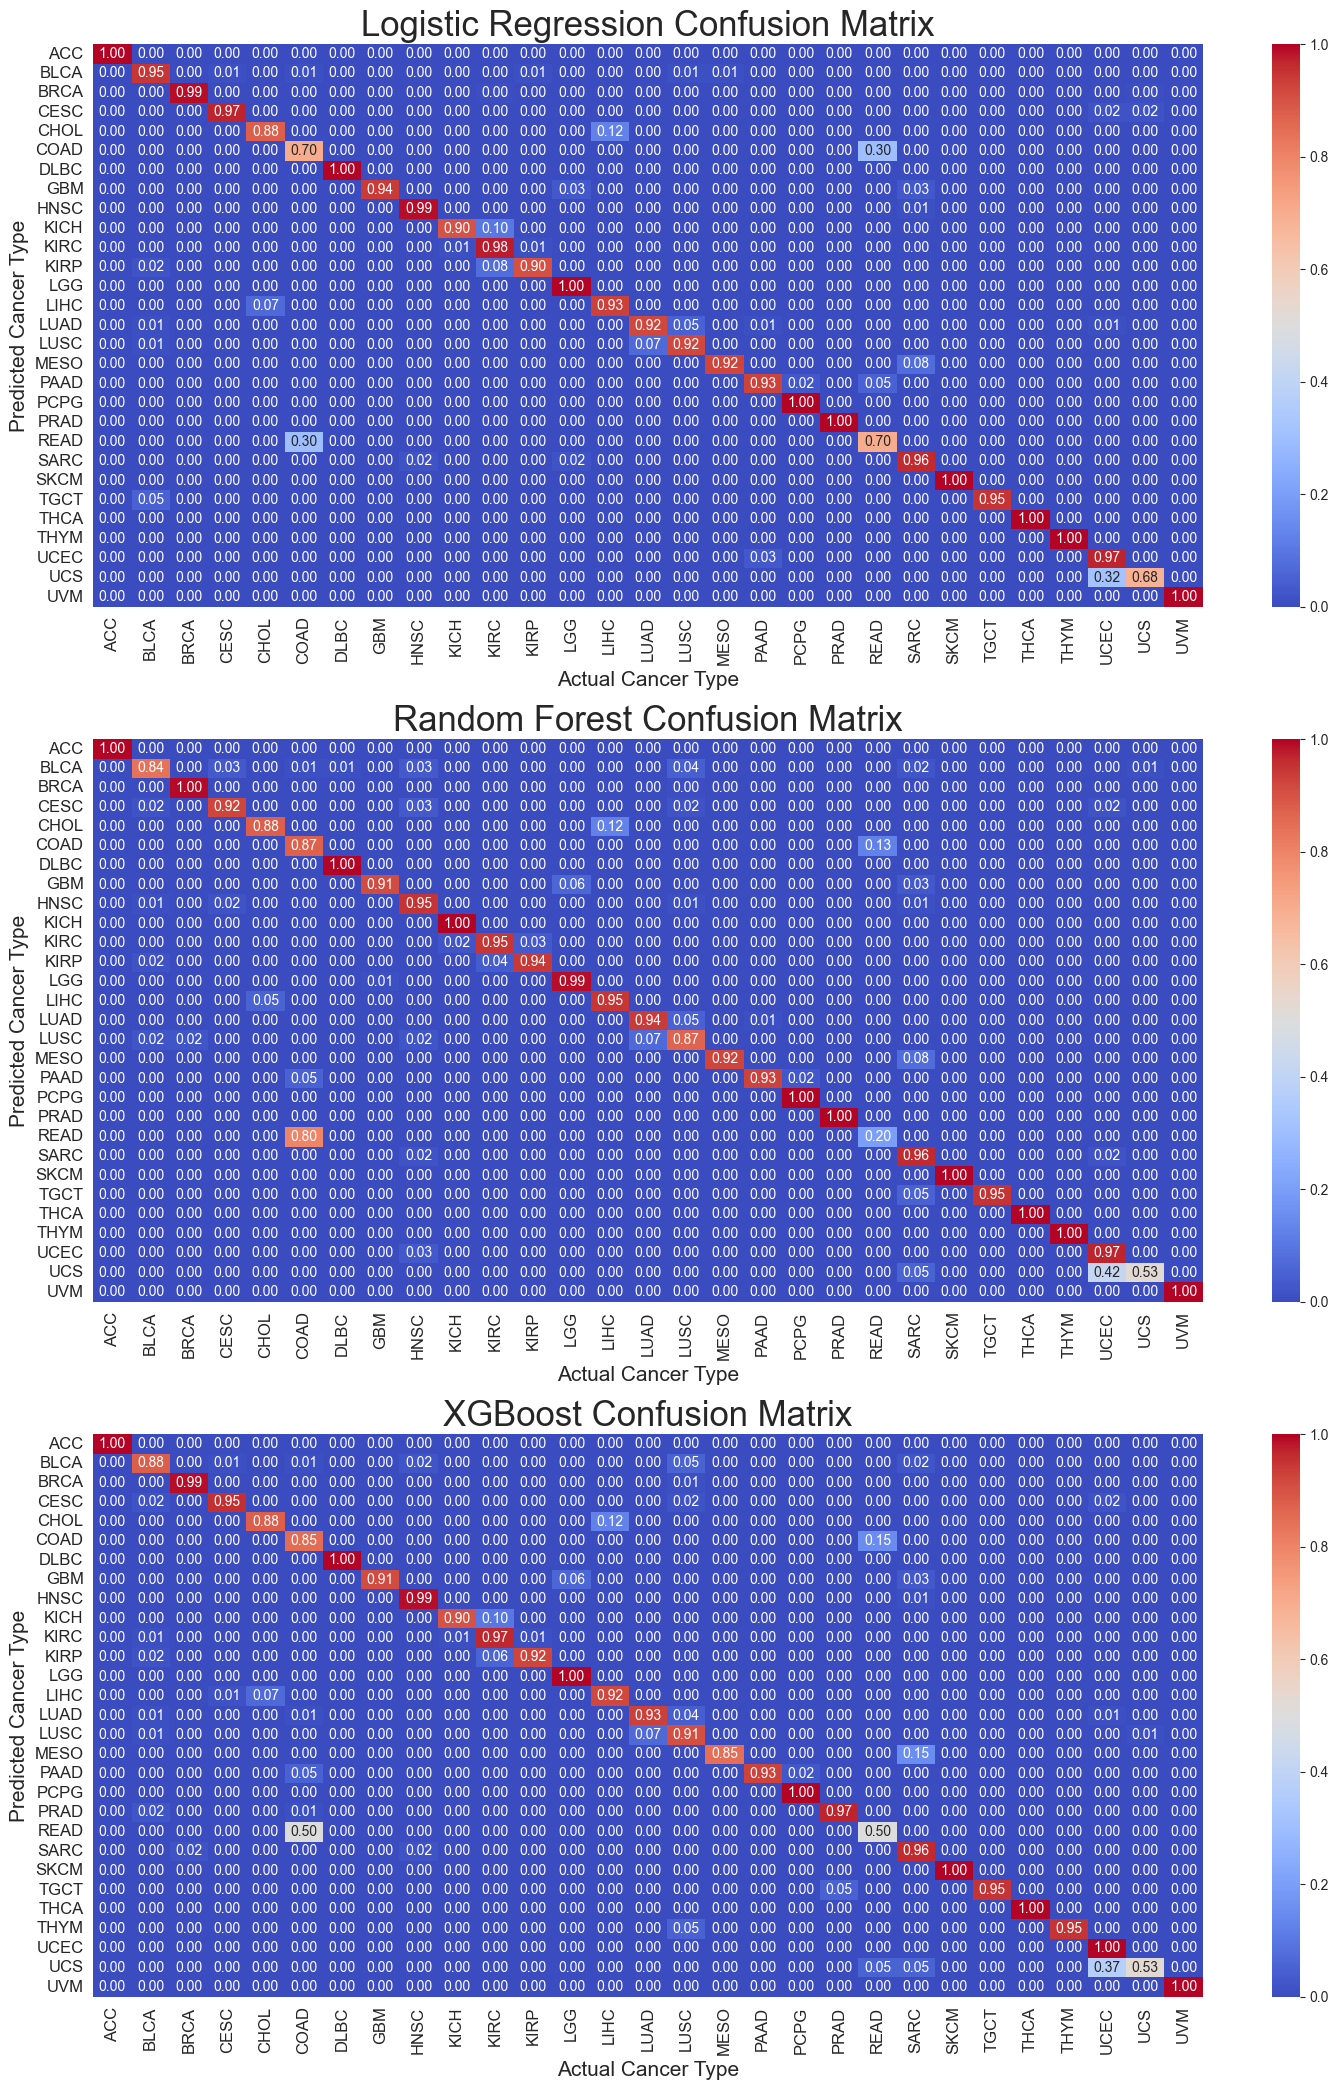

In [47]:
# Plot confusion matrices
labels = le.classes_ # get label names
models = {'Logistic Regression': final_lrclf, 'Random Forest': final_rfclf, 'XGBoost': final_xgbclf}
y_hats = [] # store y_hats in list to use for metrics below to prevent need for recomputing

plt.figure(figsize=(15, 7 * len(models)))
for i, (model_name, model) in enumerate(models.items(), 1):
    if model_name == 'XGBoost':
        y_hat = le.inverse_transform(model.predict(X_test.to_numpy()))
    else:
        y_hat = model.predict(X_test)
    y_hats.append(y_hat)

    cm = confusion_matrix(y_test, y_hat)
    # Rows will be normalized to show proportion of correct predictions rather than raw vals to account for class imbalance
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.subplot(len(models), 1, i)
    sns.heatmap(cm_norm, cmap="coolwarm", annot=True, xticklabels=labels, yticklabels=labels, fmt=".2f")

    plt.title(f"{model_name} Confusion Matrix", fontsize=25)
    plt.xlabel("Actual Cancer Type", fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylabel("Predicted Cancer Type", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"confusion_matrices.png", dpi=600)

plt.show()

## Classification Reports

In [32]:
for model, y_hat in zip(models, y_hats):
    print(f"{model} Report:")
    print(classification_report(y_test, y_hat, target_names=labels))

Logistic Regression Report:
              precision    recall  f1-score   support

         ACC       1.00      1.00      1.00        22
        BLCA       0.96      0.95      0.95        92
        BRCA       1.00      0.99      1.00       226
        CESC       0.98      0.97      0.98        64
        CHOL       0.58      0.88      0.70         8
        COAD       0.89      0.70      0.79        47
        DLBC       1.00      1.00      1.00        10
         GBM       1.00      0.94      0.97        34
        HNSC       0.99      0.99      0.99       105
        KICH       0.90      0.90      0.90        10
        KIRC       0.94      0.98      0.96        94
        KIRP       0.96      0.90      0.93        52
         LGG       0.98      1.00      0.99        88
        LIHC       0.99      0.93      0.96        75
        LUAD       0.93      0.92      0.93       101
        LUSC       0.94      0.92      0.93       100
        MESO       0.92      0.92      0.92        13

Given the highly imbalanced nature of the dataset, the F1-score is the most insightful metric from the classification reports above, as it is less influenced by class imbalance than raw precision, recall, and accuracy. Although all three classifiers yielded high weighted and macro F1-scores, careful review of the classification reports reveals that all models received exceptionally poor F1-scores when predicting COAD and READ. This is perhaps unsurprising, as these two cancer types (colon adenocarcinoma and rectum adenocarcinoma, respectively) are very similar. As stated by the Cancer Genome Atlas Network in their paper "Comprehensive molecular characterization of human colon and rectal cancer", non-hypermutated adenocarcinomas of the colon and rectum are not distinguishable at the genomic level (source: https://www.nature.com/articles/nature11252#Sec9). This example highlights the importance of using a variety of sources when classifying cancer types rather than just gene expression profiles.

# Analysis

This notebook explored using various supervised learning techniques to classify cancer type based on gene expression. All models achieved scores above 0.9, indicating high predictive capabilities. Careful analysis of results, however, revealed that all models performed poorly when differentiating specific cancer types, especially COAD and READ. This can be explained by the genetic similarities of certain cancer types. Further, despite implementing SMOTE oversampling and setting class_weight='balanced' when applicable, the severe class imbalance likely influenced results. In order to develop a more general and holistic model, a more balanced dataset can be used.

One of the greatest limitations of the models above is that they assume that input samples are cancerous. Although the original TCGA datasets do include non-cancerous samples, these samples were deliberately excluded in model development. Recall that the datasets provided by TCGA assign the cancer diagnosis to the patient and not the sample, and that the tissue type of each sample is indicated by the sample barcode. However, the non-cancer tissue types are far too broad to draw meaningful biological insights (link to sample codes: https://gdc.cancer.gov/resources-tcga-users/tcga-code-tables/sample-type-codes). Future improvements on these models could be largely focused on accounting for non-cancerous samples, as this would eliminate the assumption that sample types are cancerous and lead to a more insightful model.